# Initialize

In [ ]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np


os.chdir("..")  # Change root dir to project folder
print(os.getcwd())

import utils.paths as paths

In [ ]:
mm = 1 / 25.4  # mm in inches
fig_width = 90 * mm
# plt.rcParams.update({"font.size": 5})
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "figure.constrained_layout.use": True,
        "figure.dpi": 150,
        "font.family": "Nimbus Roman",
        "font.size": 4.5,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Nimbus Roman",
        "mathtext.it": "Nimbus Roman:italic",
        "mathtext.bf": "Nimbus Roman:bold",
        "mathtext.cal": "Nimbus Roman:italic",
        "text.usetex": False,
        "legend.frameon": False,
    }
)

# Output settings
output_parent = paths.ANALYSIS_PARENT / "paper_plots_III"
savefig_kw = dict(dpi=200, bbox_inches="tight", pad_inches=0)

# Print numerical values

## Pixel Scaling

In [ ]:
from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
scaler.__dict__

## Dataset length

In [ ]:
import data.sets.datasets as datasets
import itertools
from tqdm import tqdm

lengths = {}

# Load datasets
dset_kwargs = dict(
    dset="micromaps-DR3-opt-1024",
    dset_lookup=paths.MICROMAP_SUBSETS_ARROW_HOPPER,
)
for split, max_beam in tqdm(
    itertools.product(
        ["train", "val", "test"],
        [None, 6],
    ),
    total=6,
):
    dset_kwargs["split"] = split
    dset_kwargs["max_beam_arcsec"] = max_beam
    dset = datasets.MicromapDatasetHF(
        **dset_kwargs,
    )
    if lengths.get(max_beam) is None:
        lengths[max_beam] = {split: len(dset)}
        continue
    lengths[max_beam][split] = len(dset)

In [ ]:
from pprint import pprint

pprint(lengths)

for beam in lengths:
    print(f"Beam {beam}: {sum(lengths[beam].values())} samples")

# Result Plots

## Prepare

In [ ]:
out_path = output_parent / "results"
savefig_kw.update(dict(pad_inches=0.02))
out_path.mkdir(parents=True, exist_ok=True)

from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
import plotting.utils

reload(plotting.utils)
from plotting.utils import auto_log_bins, set_min_counts


def reconstruction_scatter_plot(
    input_pixels,
    output_pixels,
    log=False,
    logbins=False,
    plot_points=True,
    plot_sigma_range=False,
    n_bins=20,
    min_counts=20,
    label=None,
    fig_ax=None,
    axis_labels=True,
    legend=True,
    plot_id_line=True,
    figsize=(fig_width / 2,)*2
):
    fig, ax = fig_ax or plt.subplots(1, 1, figsize=figsize)
    scatter_color = plt.get_cmap("viridis")(0.1)
    range_color = plt.get_cmap("viridis")(0.75)

    # Scatter plot^
    scatter_kw = dict(s=0.5, alpha=0.6, label=label, color=scatter_color)
    match plot_points:
        case True:
            ax.scatter(input_pixels, output_pixels, **scatter_kw)
        case int():
            # Select randomly
            idxs = np.random.choice(len(input_pixels), size=plot_points, replace=False)
            ax.scatter(input_pixels[idxs], output_pixels[idxs], **scatter_kw)
        case False:
            pass
        case _:
            raise ValueError("plot_points must be a boolean or an integer.")

    # binning for median and 1-sigma
    if plot_sigma_range:
        if log or logbins:
            bin_edges = auto_log_bins([input_pixels, output_pixels], num=n_bins)
            counts, _ = np.histogram(input_pixels, bins=bin_edges)
            counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
            bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))
        else:
            bin_edges = np.linspace(
                min(input_pixels.min(), output_pixels.min()),
                max(input_pixels.max(), output_pixels.max()),
                n_bins + 1,
            )
            counts, _ = np.histogram(input_pixels, bins=bin_edges)
            counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

        digitized = np.digitize(input_pixels, bin_edges)
        medians, means, sigmas_low, sigmas_high = [
            np.zeros(len(bin_edges) - 1) for _ in range(4)
        ]
        for j in range(1, len(bin_edges)):
            bin_vals = output_pixels[digitized == j]
            if len(bin_vals):
                medians[j - 1] = np.median(bin_vals)
                means[j - 1] = np.mean(bin_vals)
                sigmas_low[j - 1] = np.percentile(bin_vals, 16)
                sigmas_high[j - 1] = np.percentile(bin_vals, 84)

        if log:
            nonzero_mask = medians > 0
            bin_centers = bin_centers[nonzero_mask]
            medians = medians[nonzero_mask]
            means = means[nonzero_mask]
            sigmas_low = sigmas_low[nonzero_mask]
            sigmas_high = sigmas_high[nonzero_mask]

        # Plot lines
        ax.stairs(
            medians,
            bin_edges,
            baseline=None,
            color=range_color,
            lw=1,
            label="Binned median",
        )
        ax.stairs(
            sigmas_high,
            bin_edges,
            baseline=sigmas_low,
            color=range_color,
            fill=True,
            alpha=0.5,
            label="16-84th percentile",
        )

        # # Plot lines
        # ax.plot(
        #     bin_centers,
        #     medians,
        #     color=range_color,
        #     lw=2,
        #     label="Binned median",
        # )
        # ax.fill_between(
        #     bin_centers,
        #     sigmas_high,
        #     sigmas_low,
        #     color=range_color,
        #     alpha=0.4,
        #     label="16-84th percentile",
        # )

    # Set axis labels
    if type(axis_labels) == bool:
        axis_labels = (axis_labels, axis_labels)

    if axis_labels[0]:
        ax.set_xlabel("Original Pixels")
    if axis_labels[1]:
        ax.set_ylabel("Reconstructed Pixels")
    ax.ticklabel_format(style="sci", scilimits=(0, 0))

    # Plot 1:1 line
    if plot_id_line:
        ax.axline(
            [
                input_pixels.mean(),
            ]
            * 2,
            slope=1,
            ls="--",
            color="red",
            alpha=0.3,
        )

    # Set axis scales
    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # Set equal limits for x and y
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    minlim, maxlim = min(xmin, ymin), max(xmax, ymax)
    ax.set_xlim(minlim, maxlim)
    ax.set_ylim(minlim, maxlim)

    # Legend
    if legend:
        ax.legend(loc="upper left")
    return fig, ax

In [ ]:
import plotting.utils

reload(plotting.utils)
from plotting.utils import auto_log_bins, set_min_counts


def reconstruction_error_plot(
    input_pixels,
    output_pixels,
    log=False,
    logbins=False,
    plot_points=True,
    plot_sigma_range=False,
    n_bins=20,
    bins=None,
    min_counts=20,
    label=None,
    fig_ax=None,
    axis_labels=True,
    legend=True,
    plot_id_line=True,
    figsize=(fig_width / 2,)*2
):
    fig, ax = fig_ax or plt.subplots(1, 1, figsize=figsize)
    scatter_color = plt.get_cmap("viridis")(0.1)
    range_color = plt.get_cmap("viridis")(0.75)

    # Scatter plot^
    scatter_kw = dict(s=0.5, alpha=0.6, label=label, color=scatter_color)
    match plot_points:
        case True:
            ax.scatter(input_pixels, output_pixels, **scatter_kw)
        case False:
            pass
        case int():
            # Select randomly
            idxs = np.random.choice(len(input_pixels), size=plot_points, replace=False)
            ax.scatter(input_pixels[idxs], output_pixels[idxs], **scatter_kw)
        case _:
            raise ValueError("plot_points must be a boolean or an integer.")

    # binning for median and 1-sigma
    if plot_sigma_range:
        if log or logbins:
            bin_edges = bins if bins is not None else auto_log_bins([input_pixels,], num=n_bins)
            counts, _ = np.histogram(input_pixels, bins=bin_edges)
            counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
            bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))
        else:
            bin_edges = bins if bins is not None else np.linspace(
                input_pixels.min(),
                input_pixels.max(),
                n_bins + 1,
            )
            counts, _ = np.histogram(input_pixels, bins=bin_edges)
            counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

        digitized = np.digitize(input_pixels, bin_edges)
        medians, means, sigmas_low, sigmas_high = [
            np.zeros(len(bin_edges) - 1) for _ in range(4)
        ]
        for j in range(1, len(bin_edges)):
            bin_vals = output_pixels[digitized == j]
            if len(bin_vals):
                medians[j - 1] = np.median(bin_vals)
                means[j - 1] = np.mean(bin_vals)
                sigmas_low[j - 1] = np.percentile(bin_vals, 16)
                sigmas_high[j - 1] = np.percentile(bin_vals, 84)

        # if log:
        #     nonzero_mask = medians > 0
        #     bin_centers = bin_centers[nonzero_mask]
        #     medians = medians[nonzero_mask]
        #     means = means[nonzero_mask]
        #     sigmas_low = sigmas_low[nonzero_mask]
        #     sigmas_high = sigmas_high[nonzero_mask]

        # Plot lines
        ax.stairs(
            medians,
            bin_edges,
            baseline=None,
            color=range_color,
            lw=1,
            label="Binned median",
        )
        ax.stairs(
            sigmas_high,
            bin_edges,
            baseline=sigmas_low,
            color=range_color,
            fill=True,
            alpha=0.5,
            label="16-84th percentile",
        )

        # # Plot lines
        # ax.plot(
        #     bin_centers,
        #     medians,
        #     color=range_color,
        #     lw=2,
        #     label="Binned median",
        # )
        # ax.fill_between(
        #     bin_centers,
        #     sigmas_high,
        #     sigmas_low,
        #     color=range_color,
        #     alpha=0.4,
        #     label="16-84th percentile",
        # )

    # Set axis labels
    if type(axis_labels) == bool:
        axis_labels = (axis_labels, axis_labels)

    if axis_labels[0]:
        ax.set_xlabel("Original Pixels")
    if axis_labels[1]:
        ax.set_ylabel("Reconstructed Pixels")
    ax.ticklabel_format(style="sci", scilimits=(0, 0))

    # Plot 1:1 line
    if plot_id_line:
        ax.axline(
            [
                input_pixels.mean(),
            ]
            * 2,
            slope=1,
            ls="--",
            color="red",
            alpha=0.3,
        )

    # Set axis scales
    if log:
        ax.set_xscale("log")
        # ax.set_yscale("log")

    # # Set equal limits for x and y
    # xmin, xmax = ax.get_xlim()
    # ymin, ymax = ax.get_ylim()
    # minlim, maxlim = min(xmin, ymin), max(xmax, ymax)
    # ax.set_xlim(minlim, maxlim)
    # ax.set_ylim(minlim, maxlim)

    # Legend
    if legend:
        ax.legend(loc="upper left")
    return fig, ax

In [ ]:
def source_matching_scatter_plot(
    all_inp,
    all_outp,
    n_bins=20,
    min_counts=20,
):
    titles = ["Total Flux (Jy/beam)", "Peak Flux (Jy)", "Major Axis (arcsec)"]
    label = None
    scatter_color = plt.get_cmap("viridis")(0.1)
    range_color = plt.get_cmap("viridis")(0.75)

    fig, axs = plt.subplots(1, 3, figsize=(180*mm, 60*mm))
    for i, title in enumerate(titles):
        ax = axs[i]

        # Scatter plot
        ax.scatter(
            all_inp[i], all_outp[i], s=0.5, alpha=0.6, label=label, color=scatter_color
        )
        if label is not None:
            ax.legend()

        # binning for median and 1-sigma
        bin_edges = auto_log_bins([all_inp[i], all_outp[i]], num=n_bins)
        counts, _ = np.histogram(all_inp[i], bins=bin_edges)
        counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
        bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))
        digitized = np.digitize(all_inp[i], bin_edges)
        medians, means, sigmas_low, sigmas_high = [
            np.zeros(len(bin_edges) - 1) for _ in range(4)
        ]
        for j in range(1, len(bin_edges)):
            bin_vals = all_outp[i][digitized == j]
            if len(bin_vals):
                medians[j - 1] = np.median(bin_vals)
                means[j - 1] = np.mean(bin_vals)
                sigmas_low[j - 1] = np.percentile(bin_vals, 16)
                sigmas_high[j - 1] = np.percentile(bin_vals, 84)
        nonzero_mask = medians > 0
        bin_centers = bin_centers[nonzero_mask]
        medians = medians[nonzero_mask]
        means = means[nonzero_mask]
        sigmas_low = sigmas_low[nonzero_mask]
        sigmas_high = sigmas_high[nonzero_mask]

        # Plot lines
        ax.stairs(
            medians,
            bin_edges,
            baseline=None,
            color=range_color,
            lw=1,
            label="Binned median",
        )
        ax.stairs(
            sigmas_high,
            bin_edges,
            baseline=sigmas_low,
            color=range_color,
            fill=True,
            alpha=0.5,
            label="16-84th percentile",
        )

        # Plot lines
        # ax.plot(
        #     bin_centers[nonzero_mask],
        #     medians,
        #     color=range_color,
        #     lw=2,
        #     label="Binned median",
        # )
        # ax.fill_between(
        #     bin_centers[nonzero_mask],
        #     sigmas_high,
        #     sigmas_low,
        #     color=range_color,
        #     alpha=0.4,
        #     label="16-84th percentile",
        # )

        # Set axis labels
        ax.set_xlabel("Input - " + title.replace("_", " "))
        ax.set_ylabel("Output - " + title.replace("_", " "))

        # Plot 1:1 line
        ax.axline(
            [
                all_inp[i].mean(),
            ]
            * 2,
            slope=1,
            ls="--",
            color="red",
            alpha=0.3,
        )

        # Set axis scales
        ax.set_xscale("log")
        ax.set_yscale("log")

        # Set equal limits for x and y
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        minlim, maxlim = min(xmin, ymin), max(xmax, ymax)
        ax.set_xlim(minlim, maxlim)
        ax.set_ylim(minlim, maxlim)

    return fig, axs

## VAE Fidelity Plots

Load Test Set

In [ ]:
from data.sets.datasets import MicromapDatasetHF
from data.trf.transforms import WebdatasetTransformCrop
from functools import partial
from plotting.images import plot_image_grid

out_path_sub = out_path / "VAE"
out_path_sub.mkdir(exist_ok=True)

cutouts_set = MicromapDatasetHF(
    "micromaps-DR3-opt-1024",
    split="test",
    max_beam_arcsec=6,
)

encodings_set = MicromapDatasetHF(
    "micromap-encodings-DR3-opt-1024",
    split="test",
    max_beam_arcsec=6,
)

assert (
    cutouts_set.dataset["__key__"] == encodings_set.dataset["__key__"]
), "Datasets are not aligned. Check that the same split and keys are used."

from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
# Select n random samples
n = 256
seed = 42
np.random.seed(seed)
idxs = np.random.choice(len(cutouts_set), size=n, replace=False)
cutouts_sel = cutouts_set.select(idxs)
encodings_sel = encodings_set.select(idxs)

# Make numpy arrays
cutouts = np.array(cutouts_sel.dataset["npy"])
encodings = np.array(encodings_sel.dataset["npy"])

# Apply center crop
from torchvision.transforms.v2 import CenterCrop

image_size = 512
f_vae = 4

crop_imgs, crop_encs = [CenterCrop(s) for s in (image_size, image_size // f_vae)]
cutouts = crop_imgs(torch.from_numpy(cutouts).float()).numpy()
encodings = crop_encs(torch.from_numpy(encodings).float()).numpy()

minmax_kw = dict(axis=(0, 2, 3), keepdims=True)
encodings_minmax = (encodings - encodings.min(**minmax_kw)) / (
    encodings.max(**minmax_kw) - encodings.min(**minmax_kw)
)
cutouts_scaled = scaler.scale(cutouts)

Look at loaded images

In [ ]:
_ = plot_image_grid(
    cutouts_scaled[:16],
    n_rows=2,
)
_ = plot_image_grid(
    encodings_minmax[:16].sum(axis=1),
    n_rows=2,
)

Load VAE

In [10]:
import models.networks.modules

reload(models.networks.modules)
import models.vae.vqvae

reload(models.vae.vqvae)
from models.vae.vqvae import VQVAE, VQVAEInterface

vae = VQVAE.load("VQ-VAE-256-DR3opt", ckpt="best")

In [11]:
from tqdm import trange

# Decode images
device = "cuda:3"
batch_size = 16


# Prepare for decoding
vae.eval()
vae.to(device)
reconstructions = torch.zeros(cutouts_scaled.shape).to(device)
encodings_torch = torch.from_numpy(encodings).float().to(device)

# Run decoding loop
with torch.no_grad():
    for i in trange(0, len(encodings), batch_size):
        encodings_batch = encodings_torch[i : i + batch_size]
        with torch.no_grad():
            reconstructions[i : i + batch_size] = vae.decode_code(
                encodings_batch
            ).squeeze()

reconstructions = reconstructions.cpu().numpy()
vae.to("cpu")
del encodings_torch
torch.cuda.empty_cache()

rec_delta = reconstructions - cutouts_scaled
reconstructions_unscaled = scaler.inverse_scale(reconstructions)

100%|██████████| 16/16 [00:31<00:00,  1.99s/it]


Plot reconstructions

8it [00:00, 66.59it/s]


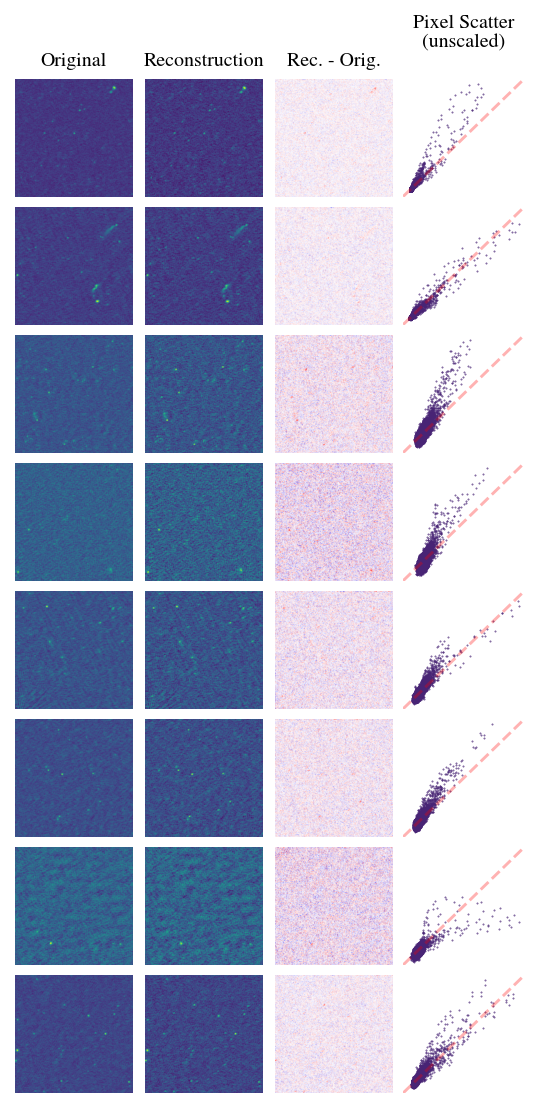

In [12]:
from tqdm import tqdm
from plotting.images import plot_image_grid

n_examples = 8

# Shape: (n_samples, 3, height, width)
plot_grid = np.stack([cutouts_scaled, reconstructions, rec_delta], axis=1)

fig, axs = plt.subplots(
    n_examples,
    4,
    figsize=(fig_width, fig_width * n_examples / 4 + 6 * mm),
    tight_layout=True,
)

for i, axrow in tqdm(enumerate(axs)):
    # Fetch images for plotting
    row_imgs = plot_grid[i]

    # Get color scale limits
    mn, mx = row_imgs[:2].min(), row_imgs[:2].max()
    amax = np.abs(row_imgs).max()

    # Plot original & reconstruction
    for j, ax in enumerate(axrow[:2]):
        ax.imshow(row_imgs[j], vmin=mn, vmax=mx, cmap="viridis")
        ax.axis("off")

    # Plot difference
    axrow[2].imshow(row_imgs[-1], vmin=-amax, vmax=amax, cmap="seismic")
    axrow[2].axis("off")

    # Scatter plot for (unscaled) pixels
    input_pixels = cutouts[i].flatten()
    output_pixels = reconstructions_unscaled[i].flatten()
    reconstruction_scatter_plot(
        input_pixels,
        output_pixels,
        log=False,
        plot_sigma_range=False,
        fig_ax=(fig, axrow[3]),
        axis_labels=(False, False),
        legend=False,
    )
    axrow[3].axis("off")

    # Set equal axis limits for scatter plot
    xmin, xmax = axrow[3].get_xlim()
    ymin, ymax = axrow[3].get_ylim()
    axmin, axmax = min(xmin, ymin), max(xmax, ymax)
    axrow[3].set_xlim(axmin, axmax)
    axrow[3].set_ylim(axmin, axmax)

    if i == 0:
        axrow[0].set_title("Original")
        axrow[1].set_title("Reconstruction")
        axrow[2].set_title("Rec. - Orig.")
        axrow[3].set_title("Pixel Scatter\n(unscaled)")

fig.savefig(out_path_sub / "VQVAE_reconstructions.png", **savefig_kw)

fig.show()

Combined Pixel Scatter Plots

Text(0, 0.5, 'Reconstructed Pixels (Jy/beam)')

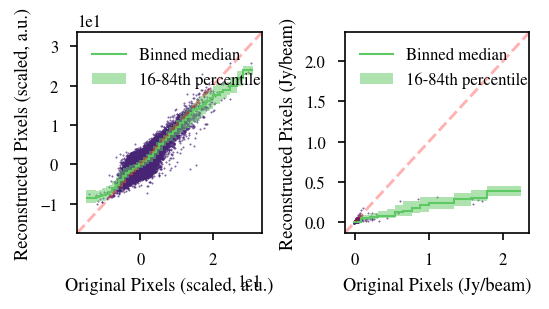

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(fig_width, fig_width * 0.55))

# Scatter plot for scaled pixels
input_pixels = cutouts_scaled.flatten()
output_pixels = reconstructions.flatten()
fig, ax = reconstruction_scatter_plot(
    input_pixels,
    output_pixels,
    plot_points=int(1e6),
    log=False,
    plot_sigma_range=True,
    n_bins=50,
    min_counts=100,
    axis_labels=(True, True),
    fig_ax=(fig, axs[0]),
)
ax.set_xlabel("Original Pixels (scaled, a.u.)")
ax.set_ylabel("Reconstructed Pixels (scaled, a.u.)")
# fig.savefig(out_path_sub / "VQVAE_scatter_scaled.png", **savefig_kw)

# Scatter plot for unscaled pixels
input_pixels = cutouts.flatten()
output_pixels = reconstructions_unscaled.flatten()
fig, ax = reconstruction_scatter_plot(
    input_pixels,
    output_pixels,
    plot_points=int(1e6),
    log=False,
    logbins=False,
    plot_sigma_range=True,
    n_bins=20,
    min_counts=25,
    axis_labels=(True, True),
    fig_ax=(fig, axs[1])
)
ax.set_xlabel("Original Pixels (Jy/beam)")
ax.set_ylabel("Reconstructed Pixels (Jy/beam)")
# fig.savefig(out_path_sub / "VQVAE_scatter_unscaled.png", **savefig_kw)

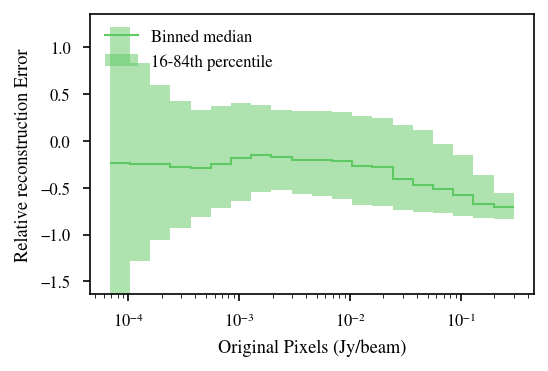

In [14]:
# Scatter plot for unscaled pixels
input_pixels = cutouts.flatten()
output_pixels = reconstructions_unscaled.flatten()
fig, ax = reconstruction_error_plot(
    input_pixels,
    (output_pixels - input_pixels) / input_pixels,
    plot_points=False,
    log=True,
    logbins=True,
    plot_sigma_range=True,
    n_bins=20,
    bins=np.geomspace(6.8e-5, 3e-1, 21),
    min_counts=25,
    axis_labels=(True, True),
    plot_id_line=False,
    figsize=(fig_width, fig_width*2/3)
)
ax.set_xlabel("Original Pixels (Jy/beam)")
ax.set_ylabel("Relative reconstruction Error")
# ax.set_ylim(-5, 5)
fig.savefig(out_path_sub / "VQVAE_reconstruction_error_unscaled.png", **savefig_kw)

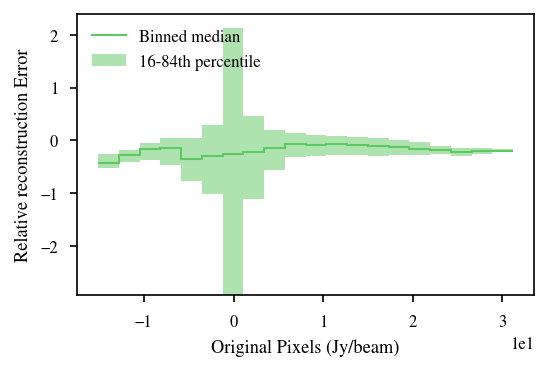

In [15]:
# Scatter plot for unscaled pixels
input_pixels = cutouts_scaled.flatten()
output_pixels = reconstructions.flatten()
nonzero = input_pixels != 0
fig, ax = reconstruction_error_plot(
    input_pixels[nonzero],
    (output_pixels - input_pixels)[nonzero] / input_pixels[nonzero],
    plot_points=False,
    log=False,
    logbins=False,
    plot_sigma_range=True,
    n_bins=20,
    # bins=np.geomspace(6.8e-5, 3e-1, 21),
    min_counts=25,
    axis_labels=(True, True),
    plot_id_line=False,
    figsize=(fig_width, fig_width*2/3)
)
ax.set_xlabel("Original Pixels (Jy/beam)")
ax.set_ylabel("Relative reconstruction Error")
# ax.set_ylim(-5, 5)
fig.savefig(out_path_sub / "VQVAE_reconstruction_error_unscaled.png", **savefig_kw)

## LDM Resampling Plots

In [ ]:
import analysis.ldm.io

reload(analysis.ldm.io)
from analysis.ldm.io import load_sweep_result

out_path_sub = out_path / "LDM"
out_path_sub.mkdir(exist_ok=True)

run_name = "slim-motif"

res = load_sweep_result(run_name, bdsf_empty_is_err=False)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

Source matching:

In [ ]:
import analysis.ldm.match as ldm_match

combined_dict, match_dicts, input_cat = ldm_match.match_sources(res)
all_inp, all_outp, all_d2d = list(combined_dict.values())

Scatter Plot:

In [ ]:
from plotting.utils import auto_log_bins


titles = ["Total Flux (Jy/beam)", "Peak Flux (Jy)", "Major Axis (arcsec)"]
label = None
scatter_color = plt.get_cmap("viridis")(0.1)
range_color = plt.get_cmap("viridis")(0.75)

fig, axs = source_matching_scatter_plot(
    all_inp,
    all_outp,
    n_bins=50,
    min_counts=25,
)

In [ ]:
fig.savefig(
    out_path_sub / "LDM_source_matching_scatter_plots.png",
    **savefig_kw,
)

Plot examples:

In [ ]:
original_imgs = original_imgs.reshape(-1, *original_imgs.shape[-2:])
original_imgs_scaled = scaler.scale(original_imgs)
# sampled_imgs = sampled_imgs.reshape(-1, *sampled_imgs.shape[-2:])

n_examples = 8
n_col = 2

fig = plt.figure(
    figsize=(180*mm, (180*mm / n_col / 2 + 2 * mm) * n_examples / n_col),
    constrained_layout=False,
    dpi=200,
)
outer = fig.add_gridspec(
    n_examples // n_col, n_col, hspace=0.05, wspace=0.05
)  # spacing between pairs

for i in range(n_examples):
    inner = outer[i].subgridspec(1, 2, wspace=0.02)  # small gap inside pair
    ax1 = fig.add_subplot(inner[0])
    ax2 = fig.add_subplot(inner[1])

    smpl = sampled_imgs[i].squeeze()
    orig = original_imgs[i]
    vmin = min(smpl.min(), np.nanmin(orig))
    vmax = max(smpl.max(), np.nanmax(orig))

    im_kw = dict(vmin=vmin, vmax=vmax, cmap="viridis")

    ax1.imshow(orig, **im_kw)
    ax2.imshow(smpl, **im_kw)

    ax1.axis("off")
    ax2.axis("off")

    if i < n_col:
        ax1.set_title("Original")
        ax2.set_title("Sampled")


# fig.show()
fig.canvas.draw()
custom_kw = dict(bbox_inches="tight")
fig.savefig(out_path_sub / "LDM_examples.png", **(savefig_kw | custom_kw))

plt.show()

## SWIIT Sampling Plots

Load run result

In [ ]:
from analysis.ldm.io import load_sweep_result

out_path_sub = out_path / "SWIIT"
out_path_sub.mkdir(exist_ok=True)

run_name = "timid-marker"

res = load_sweep_result(run_name, bdsf_empty_is_err=False)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

Source matching:

In [ ]:
import analysis.ldm.match as ldm_match

combined_dict, match_dicts, input_cat = ldm_match.match_sources(res)
all_inp, all_outp, all_d2d = list(combined_dict.values())

Scatter Plot:

In [ ]:
import plotting.utils

reload(plotting.utils)

from plotting.utils import auto_log_bins, set_min_counts

fig, axs = source_matching_scatter_plot(
    all_inp,
    all_outp,
    n_bins=50,
    min_counts=25,
)

In [ ]:
fig.savefig(
    out_path_sub / "reconstruction_scatter_plots_sampled.png",
    **savefig_kw,
)

Plot examples:

In [ ]:
original_imgs_scaled.shape, sampled_imgs.shape

In [ ]:
from plotting.images import plot_image_grid
from itertools import islice

n_examples = 16
original_imgs_scaled = scaler.scale(original_imgs).reshape(
    -1, *original_imgs.shape[-2:]
)
# sampled_imgs = sampled_imgs.reshape(-1, *sampled_imgs.shape[-2:])

for i, (smpl, orig) in enumerate(
    islice(zip(sampled_imgs, original_imgs_scaled), n_examples)
):
    fig, axs = plot_image_grid(
        [orig, smpl],
        n_cols=2,
        figsize=(180*mm, 90*mm),
    )
    axs[0].set_title("Original Image (scaled)")
    axs[1].set_title("SWIIT Sampled Image (scaled)")
    fig.savefig(
        out_path_sub / f"SWIIT_example_{i:02d}.png",
        **savefig_kw,
    )

# Decoder Blending Plots

Load Settings & Scaler

In [ ]:
from plotting.images import plot_image_grid
from tqdm import tqdm

import analysis.ldm.resample as ldmr

reload(ldmr)
dfts = ldmr.DEFAULT_SETTINGS.copy()
dfts.set(
    seed=69,
    sampling_steps=(2, 3),
    denoiser="LDM-Denoiser-WnetCC-v4",
    batch_size=1,
)

from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

out_path = output_parent / "decode_blending"
out_path.mkdir(exist_ok=True)

Load Catalog

In [ ]:
# Load LoTSS DR3 catalog
from data.utils import load_lotss_catalog

lotss_cat = load_lotss_catalog(
    select_cols=[
        "Source_Name",
        "RA",
        "DEC",
        "Total_flux",
        "Peak_flux",
        "Maj",
        # "Mosaic_ID",
    ],
    path=paths.LOFAR_DATA_PARENT_HOPPER / "LoTSS_DR3_v0.5.srl.parquet",
)

Load Resampling Blueprint

In [ ]:
mosaic = "P058+44"

img_cut, ctxt_red, ctxt_cat = ldmr.get_mosaic_blueprint(
    mosaic, dfts.img_map_size, cat=lotss_cat
)

# Get extended context map
_, ext_ctxt_red, _ = ldmr.get_mosaic_blueprint(
    mosaic, dfts.extended_ctxt_size, cat=lotss_cat
)

fig, ax = plot_image_grid([scaler.scale(img_cut)])

Load Sampler

In [ ]:
import models.ldm.swiit_sampler

reload(models.ldm.swiit_sampler)
from models.ldm.swiit_sampler import SWIITSampler

icm_sampler = ldmr.auto_kwargs(
    SWIITSampler,
    dfts,
    run=True,
)

Run Sampling

In [ ]:
torch.manual_seed(dfts.seed)
seed_noise_map = torch.randn(dfts.batch_size, 3, *dfts.latent_map_size)

In [ ]:
from pprint import pprint

sampling_kw = ldmr.auto_kwargs(icm_sampler.sample, dfts, run=False)

pprint(sampling_kw)

map_sampled, latent_sampled = icm_sampler.sample(
    ctxt_map=torch.from_numpy(ctxt_red).to(torch.float32),
    seed_noise_map=seed_noise_map,
    **sampling_kw
)

In [ ]:
# Save
np.savez(
    out_path / "sampled.npz",
    latent_sampled=latent_sampled,
    map_sampled=map_sampled,
)

Plot latent map

In [ ]:
minmax_kw = dict(axis=(0, 2, 3), keepdims=True)
latent_minmax = (latent_sampled - latent_sampled.min(**minmax_kw)) / (
    latent_sampled.max(**minmax_kw) - latent_sampled.min(**minmax_kw)
)

fig, axs = plot_image_grid(
    latent_minmax.sum(axis=1),
)
fig.savefig(out_path / "sampled_latent.png", **savefig_kw)

Plot blend patterns

In [ ]:
plt.imshow(icm_sampler.get_blending_patch(1, 2)[0] == 1)

In [ ]:
cmap = "Greys"

for i, j in [(1, 2), (2, 1), (2, 2)]:
    blend, _ = icm_sampler.get_blending_patch(i, j)
    fig, ax = plot_image_grid([blend], cmap=cmap)
    fig.show()
    fig.savefig(out_path / f"blend_{i}_{j}.png", **savefig_kw)
    fig, ax = plot_image_grid([1 - blend], cmap=cmap)
    fig.show()
    fig.savefig(out_path / f"blend_inv_{i}_{j}.png", **savefig_kw)

Plot decoded map at different stages

In [ ]:
pprint(dfts)

In [ ]:
# Re-create logic from sampler:
height_steps, width_steps = dfts.sampling_steps
total_steps = height_steps * width_steps
batch_size = dfts.batch_size
latent_map_height, latent_map_width = dfts.latent_map_size
decoding_stride = dfts.decoding_stride

latent_map = torch.from_numpy(latent_sampled).to(icm_sampler.device)
icm_sampler.vae.to(icm_sampler.device)

map_image_stacked = torch.zeros(
    total_steps + 1,
    batch_size,
    latent_map_height * icm_sampler.f_vae,
    latent_map_width * icm_sampler.f_vae,
)
map_image = map_image_stacked[0].clone()
decoded_steps = torch.zeros(
    total_steps,
    batch_size,
    dfts.image_size,
    dfts.image_size,
)
steps_from_previous = torch.zeros(
    total_steps,
    dfts.image_size,
    dfts.image_size,
)

# Initialize sampling step index used throughout loop
i_step = 0
pbar = tqdm(total=total_steps, desc="Decoding latents", unit="step")

# Iterate over steps again, now to decode the latent images.
# We can start at 1 because no double-sampling is needed for decoding.
for i in range(1, height_steps + 1):
    for j in range(1, width_steps + 1):
        # Get the latent map slice for the current sample
        slc_row, slc_col = icm_sampler.latent_map_slices_decode(
            i, j, stride=decoding_stride
        )

        # Get the sampled latent image for the current sample
        latent = latent_map[:, :, slc_row, slc_col].to(icm_sampler.device)

        # Decode the sampled latent image to pixel space
        with torch.no_grad():
            sampled_image = icm_sampler.vae.decode(latent).cpu().squeeze()

        decoded_steps[i_step] = sampled_image.clone()

        # Get slices of image location on the final map product
        img_stride = (
            decoding_stride * icm_sampler.f_vae
            if decoding_stride is not None
            else icm_sampler.config.img_stride
        )
        slc_row_img, slc_col_img = icm_sampler._make_2d_slices(
            i - 1, j - 1, icm_sampler.image_size, stride=img_stride
        )

        # Make a temporary empty image for blended adding
        sampled_image_step = torch.zeros(
            batch_size,
            latent_map_height * icm_sampler.f_vae,
            latent_map_width * icm_sampler.f_vae,
        )
        # Place the sampled image in the corresponding location
        sampled_image_step[:, slc_row_img, slc_col_img] = sampled_image

        # Add the sampled image to the map image thorugh blending
        overlap = icm_sampler.image_size - img_stride
        blend_patch, blend_inv_patch = icm_sampler.get_blending_patch(
            i, j, overlap=overlap
        )
        steps_from_previous[i_step] = torch.where(
            blend_patch == 1, torch.nan, map_image[:, slc_row_img, slc_col_img]
        )
        blend_a = torch.ones_like(map_image)
        blend_a[:, slc_row_img, slc_col_img] = blend_patch.repeat(batch_size, 1, 1)
        blend_b = torch.ones_like(map_image)
        blend_b[:, slc_row_img, slc_col_img] = blend_inv_patch.repeat(batch_size, 1, 1)
        map_image = map_image * blend_b + sampled_image_step * blend_a

        # Update progress bar and sampling step index
        i_step += 1
        map_image_stacked[i_step] = map_image.clone()
        pbar.update(1)

map_image_stacked = map_image_stacked.cpu().numpy()
map_image_stacked[map_image_stacked == 0] = np.nan

In [ ]:
contour_kw = dict(
    levels=[0.5, 1.5],  # select True region only
    colors="none",  # no fill color
    hatches=["/"],  # hatch style
)
plt.rcParams.update({"hatch.linewidth": 2, "hatch.color": (0, 0, 0, 0.6)})

for i, img_step in tqdm(
    enumerate(steps_from_previous), total=len(decoded_steps), desc="Plotting steps"
):
    fig, ax = plot_image_grid(
        [img_step],
        vmin=np.nanmin(map_image_stacked),
        vmax=np.nanmax(map_image_stacked),
    )
    ax.contourf(np.isnan(img_step), **contour_kw)
    fig.savefig(out_path / f"step_from_previous_{i+1:02d}.png", **savefig_kw)

In [ ]:
for i, img_step in tqdm(
    enumerate(decoded_steps), total=len(decoded_steps), desc="Plotting steps"
):
    fig, ax = plot_image_grid(
        img_step,
        vmin=np.nanmin(map_image_stacked),
        vmax=np.nanmax(map_image_stacked),
    )
    fig.savefig(out_path / f"decoded_img_{i+1:02d}.png", **savefig_kw)

In [ ]:
contour_kw = dict(
    levels=[0.5, 1.5],  # select True region only
    colors="none",  # no fill color
    hatches=["/"],  # hatch style
)
plt.rcParams.update({"hatch.linewidth": 2, "hatch.color": (0, 0, 0, 0.6)})

for i, map_step in tqdm(
    enumerate(map_image_stacked[1:]),
    total=len(map_image_stacked) - 1,
    desc="Plotting steps",
):
    fig, ax = plot_image_grid(
        map_step,
        vmin=np.nanmin(map_image_stacked),
        vmax=np.nanmax(map_image_stacked),
    )
    ax.contourf(np.isnan(map_step[0]), **contour_kw)
    fig.savefig(out_path / f"decoded_step_{i+1:02d}.png", **savefig_kw)

# Pixel Scaling Plots

Load scaler

In [ ]:
# Load scaler
from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

## Pixel Distributions

Load example pixels

In [ ]:
# Load pixel data
import h5py

px_file = paths.LOFAR_DATA_PARENT / "random_pixels.h5"
with h5py.File(px_file, "r") as f:
    pixel_data = np.array(f["pixels"][:])
    pass

Plot Histograms

In [ ]:
from plotting.utils import auto_log_bins
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# General settings
n_bins = 75
hist_kw = dict(histtype="step", lw=1, color=plt.get_cmap("viridis")(0.2), log=True)
fontsize = "xx-large"

# Create figure
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(fig_width, fig_width * 1.5), constrained_layout=True
)

# Plot original pixel value distribution in top row
bins = np.linspace(-0.01, 0.05, n_bins)
ax1.hist(pixel_data.ravel(), bins=bins, **hist_kw, label="Original Pixels")

# Inset: full range
ax1_inset = ax1.inset_axes([0.68, 0.68, 0.3, 0.3])
ax1_inset.hist(pixel_data.ravel(), bins=n_bins, **hist_kw)
ax1_inset.tick_params(labelsize=6)

# Top axis settings
ax1.set_xlabel("Original pixel values (Jy/Beam)", fontsize=fontsize)
ax1.legend(
    # loc=(0.6, 0.45)
    loc="center right"
)

# Plot scaled pixel value distribution in bottom row
px_scaled = scaler.scale(pixel_data.ravel())
x_bin_limit = 12.5
bins_sc = np.linspace(-x_bin_limit, x_bin_limit, n_bins)
cts, _, _ = ax2.hist(px_scaled, bins=bins_sc, **hist_kw, label="Scaled Pixels")

# Plot gaussian
x_gaus = np.linspace(-x_bin_limit, x_bin_limit, 1000)
gaus = cts.max() * np.exp(-0.5 * x_gaus**2)
ax2.plot(x_gaus, gaus, color="tab:orange", lw=1, alpha=0.5, label="Gaussian")

# Inset: full range
ax2_inset = ax2.inset_axes([0.68, 0.68, 0.3, 0.3])
ax2_inset.hist(px_scaled, bins=n_bins, **hist_kw)
ax2_inset.tick_params(labelsize=6)

# Bottom axis settings
ax2.set_ylim(1e3, np.exp(1.025 * np.log(cts.max())))
ax2.set_xlabel("Scaled pixel values (a.u.)", fontsize=fontsize)
ax2.legend(loc="upper left")

# Add shared x-label for top row using fig.text()
fig.supylabel("Count", fontsize=fontsize)

plt.show()

Save figure

In [ ]:
fig.savefig(output_parent / "pixel_value_distributions.pdf", **savefig_kw)

## Example images

Load mosaic image, plot Preview:

In [ ]:
from data.utils import load_mosaic, list_mosaics
from plotting.images import plot_image_grid
from skimage.transform import rescale

# Get mosaic
seed = 69
mosaics = list_mosaics()
np.random.seed(seed)
mosaic = np.random.choice(mosaics)
print(mosaic)

mosaic_img, _ = load_mosaic(mosaic)

# Get central cutout
cutout_size = 2048
H, W = mosaic_img.shape
img_cut = mosaic_img[
    H // 2 - cutout_size // 2 : H // 2 + cutout_size // 2,
    W // 2 - cutout_size // 2 : W // 2 + cutout_size // 2,
]

img_cut_scaled = scaler.scale(img_cut)

downs = 8
plot_image_grid([rescale(mosaic_img, 1 / downs), img_cut], vmin=-0.01, vmax=0.1)
plot_image_grid([img_cut_scaled])

Make Plot

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(fig_width, fig_width * 1.4), constrained_layout=True, dpi=300
)

im1 = ax1.imshow(img_cut * 1e3, vmin=-10, vmax=50, cmap="viridis")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Original (mJy/Beam)")
ax1.axis("off")

im2 = ax2.imshow(img_cut_scaled, vmin=-12.5, vmax=12.5, cmap="seismic")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label="Scaled (a.u.)")
ax2.axis("off")

fig.show()

Save figure

In [ ]:
fig.savefig(output_parent / "pixel_value_scaling_example.pdf", **savefig_kw)

# Dataset Generation Plots

## Imports, Definitions and Loads

Required imports and functions

In [ ]:
from plotting.images import plot_image_grid
import plotting.maps

reload(plotting.maps)
from plotting.maps import plot_sky_map
from data.utils import load_fits_image, load_mosaic
import data.obs.micromaps.utils

reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import (
    get_micromap_centers,
    get_micromaps,
    context_map_by_wcs,
    single_micromap_cutout,
    reduce_context_map,
    filter_catalog_by_wcs,
)
import pandas as pd


# Convenience function for loading mosaic names
# with control over random seed, number and max beam size
def load_mosaic_names(n_mosaics=1, seed=None, max_beam_arcsec=None):
    # Get list of mosaics based on directory contents
    mosaic_list = sorted([p.name for p in paths.MOSAIC_DIR_DR3.glob("*") if p.is_dir()])

    # Filter by max beam if specified
    if max_beam_arcsec is not None:
        # Load pointing info, which includes beam sizes
        pointing_info_df = pd.read_csv(
            paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv", index_col="mosaic"
        )
        # Select good pointings, i.e. pointings with beam <= max_beam_arcsec
        good_pointings = np.array(
            pointing_info_df.index[
                pointing_info_df["Beam"] <= np.round(max_beam_arcsec / 3600, 5)
            ],
            dtype=np.str_,
        )
        # Filter mosaics by good pointings
        select_idxs = np.argwhere([p in good_pointings for p in mosaic_list]).flatten()
        mosaic_list = [mosaic_list[i] for i in select_idxs]
        # Pick randomly from remaining mosaics
        np.random.seed(seed)
        mosaics = [np.random.choice(mosaic_list) for _ in range(n_mosaics)]
        return mosaics

Settings

In [ ]:
max_beam_arcsec = 6
seed = 42

# Output settings
output_dir = output_parent / "Dataset_generation"
if not output_dir.exists():
    output_dir.mkdir(parents=True)

Load catalog

In [ ]:
# Load LoTSS DR3 catalog
from data.utils import load_lotss_catalog

lotss_cat = load_lotss_catalog(
    select_cols=[
        "Source_Name",
        "RA",
        "DEC",
        "Total_flux",
        "Peak_flux",
        "Maj",
        # "Mosaic_ID",
    ]
)

Load pixel scaler

In [ ]:
from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

## Mosaic tiling plots

In [ ]:
import plotting.images

reload(plotting.images)

from plotting.images import plot_image_grid

import data.obs.micromaps.utils

reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import get_micromap_centers, get_optimal_micromap_centers

import plotting.maps

reload(plotting.maps)
from plotting.maps import plot_sky_map

# Size that the model is trained with, i.e. half the cutout size
image_sizes = [
    # 256,
    512,
]

mosaics = ["P168+15"]  # , "P277+00", "P070+37"]
for mosaic in mosaics:
    print(f"Selected mosaic: {mosaic}")

    map_arr, wcs = load_mosaic(mosaic)

    for image_size in image_sizes:
        micromap_size = image_size * 2
        spacing = 1
        centers = get_optimal_micromap_centers(map_arr, micromap_size, spacing=spacing)
        p = np.flip(centers, axis=1)

        map_arr_scaled = scaler.scale(map_arr)
        absmax = np.nanmax(np.abs(map_arr_scaled))

        fig, ax, _ = plot_sky_map(
            np.clip(map_arr_scaled, 0, None),
            wcs=wcs,
            size=(fig_width,) * 2,
            norm_quantile=0.9999,
            cbar=False,
            scalebar_color="black",
            # cmap='bwr',
        )

        # For testing, this is quicker:
        # fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
        # im = ax.imshow(np.clip(map_arr_scaled, 0, None), origin="lower")

        ax.scatter(*p.T, s=0.5, color="red")

        # Draw square patches around the micromap centers
        for center in p:
            rect = plt.Rectangle(
                center - micromap_size / 2,
                micromap_size,
                micromap_size,
                linewidth=0.75,
                ls="-",
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

        ax.axis("off")

        fig.savefig(
            output_dir / f"cutout_tiling_{mosaic}_{micromap_size}px.png",
            **savefig_kw,
        )

        fig.show()

        micromaps, _, _ = get_micromaps(
            map_arr_scaled, micromap_size, spacing=spacing, centers=centers, wcs=wcs
        )
        fig, axs = plot_image_grid(
            micromaps,
            n_cols=7,
            n_rows=7,
            origin="lower",
        )
        fig.savefig(
            output_dir / f"cutout_tiling_{mosaic}_{micromap_size}px_cutout_grid.png",
            **savefig_kw,
        )

        fig.show()

In [ ]:
fig, axs = plot_image_grid(
    micromaps, n_cols=7, n_rows=7, origin="lower", img_side_len=(2)
)

In [ ]:
from data.obs.micromaps.utils import get_micromaps

mosaic = "P168+15"
map_arr, wcs = load_mosaic(mosaic)
micromaps, _, _ = get_micromaps(
    map_arr,
    micromap_size=512 * 2,
    wcs=wcs,
    spacing=1,
)

In [ ]:
micromaps.shape

Load LDM Sampler

In [ ]:
image_size = 512
mosaic = "P168+15"
print(f"Selected mosaic: {mosaic}")

map_arr, wcs = load_mosaic(mosaic)

In [ ]:
import data.obs.micromaps.utils

reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import get_micromap_centers, get_optimal_micromap_centers

micromap_size = image_size * 2
spacing = 1
p = get_micromap_centers(map_arr, micromap_size, spacing=spacing, symmetric=True)
p = np.flip(p, axis=1)

map_arr_scaled = scaler.scale(map_arr)
absmax = np.nanmax(np.abs(map_arr_scaled))

fig, ax, _ = plot_sky_map(
    np.clip(map_arr_scaled, 0, None),
    wcs=wcs,
    size=(fig_width,) * 2,
    norm_quantile=0.9999,
    cbar=False,
    scalebar_color="black",
    # cmap='bwr',
)

# For testing, this is quicker:
# fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
# im = ax.imshow(np.clip(map_arr_scaled, 0, None), origin="lower")

ax.scatter(*p.T, s=0.5, color="red")

# Draw square patches around the micromap centers
for center in p:
    rect = plt.Rectangle(
        center - micromap_size / 2,
        micromap_size,
        micromap_size,
        linewidth=0.75,
        ls="-",
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rect)


ax.axis("off")

fig.show()

# Image and Context Example Plots

In [ ]:
# Load mosaic image
mosaic = "P168+15"
map_arr, wcs = load_mosaic(mosaic)

# Load context
ctxt_map, _ = context_map_by_wcs(wcs, lotss_cat, scale_output=False)

# Get cutouts
micromap_size = 1024
map_arr_scaled = scaler.scale(map_arr)
mmaps, centers, wcss = get_micromaps(map_arr_scaled, micromap_size, wcs=wcs)

In [ ]:
mmaps.shape

In [ ]:
# Pick one as example
i_mmap = 30
mmap = mmaps[i_mmap]
center = centers[i_mmap]
wcs_mmap = wcss[i_mmap]

# Get context
ctxt = single_micromap_cutout(
    ctxt_map.transpose(1, 2, 0),
    micromap_size,
    center,
)[
    0
].transpose(2, 0, 1)
ctxt_ext = single_micromap_cutout(
    ctxt_map.transpose(1, 2, 0),
    micromap_size * 2,
    center,
)[0].transpose(2, 0, 1)

# Reduce them for plotting
f_downscale = 16
ctxt = reduce_context_map(ctxt, f_downscale=f_downscale)
ctxt_ext = reduce_context_map(ctxt_ext, f_downscale=f_downscale)

# Blank center of extended context map
if False:
    r_inner = ctxt_ext.shape[-1] // 4
    ctxt_ext[
        :,
        r_inner:-r_inner,
        r_inner:-r_inner,
    ] *= 0

In [ ]:
# Plot surroundings of micromap
mosaic_patch, wcs_patch = single_micromap_cutout(
    map_arr_scaled, int(micromap_size * 2.5), center, wcs=wcs
)
patch_cat = filter_catalog_by_wcs(lotss_cat, wcs_patch)
amax = np.nanmax(np.abs(mosaic_patch))
# mosaic_patch_scaled = scaler.scale(mosaic_patch)

from astropy.coordinates import SkyCoord

fig, ax, _ = plot_sky_map(
    np.clip(mosaic_patch, 0, mmap.max()),
    wcs=wcs_patch,
    size=(fig_width, fig_width),
    norm_quantile=None,
    cbar=False,
    scalebar_color="black",
    cmap="viridis",
)

# get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

marker_color = "red"
# marker_color = plt.get_cmap("viridis")(0.75)

ax.scatter_coord(
    SkyCoord(patch_cat["RA"], patch_cat["DEC"], unit="deg"),
    s=2,
    edgecolor=marker_color,
    facecolor="none",
    alpha=0.7,
    marker=".",
)

# Square around center
rect = plt.Rectangle(
    (
        mosaic_patch.shape[0] / 2 - micromap_size / 2,
        mosaic_patch.shape[1] / 2 - micromap_size / 2,
    ),
    micromap_size,
    micromap_size,
    linewidth=0.75,
    ls="-",
    edgecolor=marker_color,
    facecolor="none",
)
ax.add_patch(rect)

rect = plt.Rectangle(
    (
        mosaic_patch.shape[0] / 2 - micromap_size,
        mosaic_patch.shape[1] / 2 - micromap_size,
    ),
    2 * micromap_size,
    2 * micromap_size,
    linewidth=0.75,
    ls="--",
    edgecolor=marker_color,
    facecolor="none",
    alpha=0.5,
)
ax.add_patch(rect)

# Set previous axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Save
fig.savefig(
    output_dir / f"micromap_surroundings_{mosaic}_idx{i_mmap}.pdf",
    **savefig_kw,
)

In [ ]:
# Plot micromap cutout
fig, ax = plot_image_grid(
    [np.clip(mmap, 0, None)],
    figsize=(fig_width * 0.5, fig_width * 0.5 * 1.2),
    origin="lower",
)

# Set title
ax.set_title("Cutout")

# Save
fig.savefig(
    output_dir / f"micromap_cutout_{mosaic}_idx{i_mmap}.pdf",
    **savefig_kw,
)


def log1p_n(x, n):
    for _ in range(n):
        x = np.log1p(x)
    return x


# Plot context
for ctxt_arr in [ctxt_ext]:
    titles = ["Position Mask", "Total Flux", "Peak Flux", "Major Axis"]
    for i, ch in enumerate(ctxt_arr):
        fig, ax = plot_image_grid(
            [log1p_n(ch, 4)],
            n_cols=1,
            figsize=(fig_width / 4, fig_width * 1.2 / 4),
            origin="lower",
        )
        title = titles[i]

        ax.set_title(title)

        # Save
        size_label = "normal" if ctxt_arr is ctxt else "extended"
        fig.savefig(
            output_dir
            / f"micromap_context_{size_label}_{mosaic}_idx{i_mmap}_{title.replace(' ', '_')}.pdf",
            **savefig_kw,
        )

# Sampling Procedure Plots

## Helper functions

Required imports and functions

In [ ]:
from plotting.images import plot_image_grid
from tqdm import tqdm, trange

from importlib import import_module, reload
import pandas as pd

from data.utils import load_mosaic
from data.obs.micromaps.utils import (
    context_map_by_wcs,
    reduce_context_map,
    fill_nan_pixels,
)


def import_reload(module_name, package=None, attr=None):
    module = import_module(module_name, package=package)
    reload(module)
    if attr:
        return getattr(module, attr)
    return module


# Convenience function for getting the slice of the central cutout
def get_slices(img, cutout_size_px):
    match cutout_size_px:
        case int():
            cutout_size_px = (cutout_size_px, cutout_size_px)
        case (int(), int()) | [int(), int()]:
            pass
        case _:
            raise ValueError(
                f"Invalid cutout_size_px: {cutout_size_px} of type {type(cutout_size_px)}"
            )
    out = []
    for s in cutout_size_px:
        cby2, cpx = s // 2, img.shape[-1] // 2
        sl = slice(cpx - cby2, cpx + cby2)
        out.append(sl)

    return tuple(out)


# Convenience function for loading mosaic names
# with control over random seed, number and max beam size
def load_mosaic_names(n_mosaics=1, seed=None, max_beam_arcsec=None):
    # Get list of mosaics based on directory contents
    mosaic_list = sorted([p.name for p in paths.MOSAIC_DIR_DR3.glob("*") if p.is_dir()])

    # Filter by max beam if specified
    if max_beam_arcsec is not None:
        # Load pointing info, which includes beam sizes
        pointing_info_df = pd.read_csv(
            paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv", index_col="mosaic"
        )
        # Select good pointings, i.e. pointings with beam <= max_beam_arcsec
        good_pointings = np.array(
            pointing_info_df.index[
                pointing_info_df["Beam"] <= np.round(max_beam_arcsec / 3600, 5)
            ],
            dtype=np.str_,
        )
        # Filter mosaics by good pointings
        select_idxs = np.argwhere([p in good_pointings for p in mosaic_list]).flatten()
        mosaic_list = [mosaic_list[i] for i in select_idxs]
        # Pick randomly from remaining mosaics
        np.random.seed(seed)
        mosaics = [np.random.choice(mosaic_list) for _ in range(n_mosaics)]
        return mosaics


# Convenience function for getting mosaic central cutout and context map
def get_mosaic_blueprint(mosaic, cutout_size_px, cat, f_downscale=4):
    # Get mosaic and wcs data
    img, wcs = load_mosaic(mosaic)

    # Get central cutout from both image and wcs
    sl1, sl2 = get_slices(img, cutout_size_px)
    img_cut, wcs_cut = img[sl1, sl2], wcs[sl1, sl2]

    # Create context map from catalog
    ctxt, ctxt_cat = context_map_by_wcs(
        wcs_cut,
        cat,
        scale_output=False,
    )
    # Downsample context map like training data
    ctxt_red = reduce_context_map(
        ctxt,
        scale_output=False,
        input_scaled=False,
    )
    # Scale location map to [-1, 1]
    ctxt_red[0] = ctxt_red[0] * 2 - 1
    return img_cut, ctxt_red, ctxt_cat

## Load necessary stuff

Define variables for plotting

In [ ]:
# Sampling blueprint settings
quadrant_size = (4, 4)  # 256 px per quadrant (currently only squares supported)
px_per_quadrant = 256
cutout_size_px = tuple(q * px_per_quadrant for q in quadrant_size)
batch_size = 1
max_beam_arcsec = 6
seed = 42

# Sampling settings
image_size = 512
latent_size = 128
f_inner = 1
f_ext_ctxt = (2, 2)
resample_first = False

# Output settings
output_dir = paths.ANALYSIS_PARENT / "paper_plots_III/SWIIT_sampling"
if not output_dir.exists():
    output_dir.mkdir(parents=True)
savefig_kw = dict(dpi=150, bbox_inches="tight", pad_inches=0)

Load ICM Sampler for convenience

In [ ]:
ICMSampler = import_reload("models.ldm.icm_sampler_v2", attr="ICMSampler")

icm_sampler = ICMSampler(
    denoiser=None,
    uncond_denoiser=None,
    vae=None,
    image_size=image_size,
    latent_size=latent_size,
    f_inner=f_inner,
    f_ext_ctxt=f_ext_ctxt,
)

Load LoTSS catalog & sampling blueprint

In [ ]:
# Load LoTSS DR3 catalog
from data.utils import load_lotss_catalog

lotss_cat = load_lotss_catalog(
    select_cols=[
        "Source_Name",
        "RA",
        "DEC",
        "Total_flux",
        "Peak_flux",
        "Maj",
        "Mosaic_ID",
    ]
)

In [ ]:
# Load mosaic name
[mosaic] = load_mosaic_names(n_mosaics=1, seed=seed, max_beam_arcsec=max_beam_arcsec)
print(f"Selected mosaic: {mosaic}")

# Get mosaic blueprint
img_cut, ctxt_red, ctxt_cat = get_mosaic_blueprint(
    mosaic, cutout_size_px, cat=lotss_cat
)
img_cut = fill_nan_pixels(img_cut)
img_cut_scaled = icm_sampler.scaler.scale(img_cut)

# Get extended context map
_, ext_ctxt_red, _ = get_mosaic_blueprint(
    mosaic, tuple(s + 2 * px_per_quadrant for s in cutout_size_px), cat=lotss_cat
)

## Make figures:

### Seed noise

In [ ]:
seed_noise_map = np.random.randn(*ctxt_red.shape[-2:])

fig, ax = plot_image_grid([seed_noise_map])

# Add grid lines for quadrants
kw = dict(color="white", lw=1.0, alpha=0.3, ls="--")
for i in range(1, quadrant_size[0]):
    ax.axhline(i * px_per_quadrant // 4 - 0.5, **kw)
for j in range(1, quadrant_size[1]):
    ax.axvline(j * px_per_quadrant // 4 - 0.5, **kw)
fig.savefig(output_dir / "seed_noise_map.png", **savefig_kw)
fig.show()

### Context Map

In [ ]:
from scipy.ndimage import convolve

# Convolve with 3x3 unormalized kernel for visual enhancement
ctxt_enhanced = convolve(
    ctxt_red[1], weights=np.ones((3, 3)), mode="constant", cval=0.0
)

fig, ax = plot_image_grid([np.log1p(ctxt_enhanced)])
# Add grid lines for quadrants
kw = dict(color="white", lw=1.0, alpha=0.1, ls="--")
for i in range(1, quadrant_size[0]):
    ax.axhline(i * px_per_quadrant // 4 - 0.5, **kw)
for j in range(1, quadrant_size[1]):
    ax.axvline(j * px_per_quadrant // 4 - 0.5, **kw)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig(output_dir / "context_map.png", **savefig_kw)
fig.show()

### Figures for steps (0, 0), (0, 1), (0, n_q_sampled), (1, 0), (1, 1)

In [ ]:
def image_slice_at(i, j):
    slc_row = slice(i * px_per_quadrant, (i + 2) * px_per_quadrant)
    slc_col = slice(j * px_per_quadrant, (j + 2) * px_per_quadrant)
    return slc_row, slc_col


def coverage_after(i, j):
    mask = np.zeros_like(img_cut_scaled, dtype=bool)
    for ii in range(i + 1):
        for jj in range((quadrant_size[1] if ii < i else j) + 1):
            slc_row, slc_col = image_slice_at(ii, jj)
            mask[slc_row, slc_col] = True
    return mask


def inpainting_mask(q1, q2, q3, q4):
    # Shape (2, 2), indicating which quadrants are selected:
    t = torch.tensor([q1, q2, q3, q4]).float().reshape(1, 1, 2, 2)
    mask = (
        torch.nn.functional.interpolate(t, scale_factor=image_size // 2, mode="nearest")
        .squeeze()
        .to(torch.bool)
        .numpy()
    )
    return mask


import matplotlib.colors as mcolors

# Pick your target color (name, hex, or RGB tuple)
target_color = "#2dc2f4"  # example: blue

# Create colormap: gradient from white → target color
cmap = mcolors.LinearSegmentedColormap.from_list(
    "black_to_blue", ["black", target_color]
)

In [ ]:
steps = [
    (0, 0),
    (0, 1),
    (0, 2),
    (1, 0),
    (1, 1),
]

vmin = np.nanmin(img_cut_scaled)
vmax = np.nanmax(img_cut_scaled)

contour_kw = dict(
    levels=[0.5, 1.5],  # select True region only
    colors="none",  # no fill color
    hatches=["/"],  # hatch style
)
plt.rcParams.update({"hatch.linewidth": 2, "hatch.color": (0, 0, 0, 0.9)})
for step in steps:
    kw = dict(cmap=cmap, vmin=0, vmax=1)

    # Inpainting mask at step
    mask = icm_sampler.sampling_mask_for_iteration(*step).squeeze().numpy()
    fig, ax = plot_image_grid([mask], **kw)
    fig.savefig(output_dir / f"inpainting_mask_at_{step}.png", **savefig_kw)

    kw = dict(vmin=vmin, vmax=vmax)

    # Image sampled at step
    slc_row, slc_col = image_slice_at(*step)
    img_step = img_cut_scaled[slc_row, slc_col]
    fig, ax = plot_image_grid([img_step], **kw)
    fig.savefig(output_dir / f"image_sampled_at_{step}.png", **savefig_kw)

    # Inpainting context at step
    mask = (
        torch.nn.functional.interpolate(
            torch.from_numpy(mask).to(torch.float32).reshape(1, 1, *mask.shape),
            scale_factor=img_step.shape[-1] // mask.shape[-1],
            mode="nearest",
        )
        .squeeze()
        .numpy()
        .astype(bool)
    )
    inpainting_ctxt = img_step.copy()
    inpainting_ctxt[mask] = np.nan
    fig, ax = plot_image_grid([inpainting_ctxt], **kw)
    ax.contourf(np.isnan(inpainting_ctxt), **contour_kw)
    fig.savefig(output_dir / f"inpainting_context_at_{step}.png", **savefig_kw)

    # latent map after step
    latent_map = np.full_like(img_cut_scaled, np.nan)
    coverage_mask = coverage_after(*step)
    latent_map[coverage_mask] = img_cut_scaled[coverage_mask]
    fig, ax = plot_image_grid([latent_map], **kw)
    ax.contourf(np.isnan(latent_map), **contour_kw)
    fig.savefig(output_dir / f"latent_map_after_{step}.png", **savefig_kw)